# Predição de atraso de voos com Machine Learning

Este projeto tem como objetivo prever se um voo terá atraso superior a 15 minutos na saída, utilizando informações operacionais conhecidas antes da decolagem.

A variável-alvo utilizada foi `atraso_15min`, em que 0 representa voos sem atraso relevante e 1 representa voos com atraso superior a 15 minutos.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier

In [68]:
df = pd.read_csv('/content/flight_data_2024_sample.csv')

df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.00,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.00,144.00,119.00,835.00,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.00,CLT,"Charlotte, NC",North Carolina,...,0,286.00,273.00,253.00,1773.00,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.00,CHA,"Chattanooga, TN",Tennessee,...,0,59.00,50.00,29.00,106.00,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.00,OMA,"Omaha, NE",Nebraska,...,0,180.00,177.00,163.00,1099.00,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.00,BWI,"Baltimore, MD",Maryland,...,0,90.00,96.00,76.00,399.00,0,0,0,0,0


## Entendimento inicial da base

In [69]:
df.shape

(10000, 35)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

In [71]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,0
origin,0
origin_city_name,0
origin_state_nm,0


## Análise de valores nulos

Nesta etapa, verifiquei quais colunas possuem valores ausentes e qual o percentual de impacto na base.

In [72]:
nulos = df.isnull().sum()
percentual_nulos = (nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'valores_nulos': nulos,
    'percentual': percentual_nulos
})

resumo_nulos[resumo_nulos['valores_nulos'] > 0].sort_values(
    by='percentual',
    ascending=False
)

,valores_nulos,percentual
cancellation_code,9878,98.78
air_time,164,1.64
arr_delay,164,1.64
actual_elapsed_time,164,1.64
taxi_in,127,1.27
wheels_on,127,1.27
arr_time,127,1.27
taxi_out,120,1.20
wheels_off,120,1.20
dep_delay,116,1.16


## Distribuição dos atrasos de saída

Antes da modelagem, é importante entender como os atrasos se comportam na base. Nesta etapa, eu fiz a analise e a distribuição da variável `dep_delay`.

In [73]:
df['dep_delay'].describe()

,dep_delay
count,9884.00
mean,13.00
std,53.61
min,-22.00
25%,-6.00
50%,-2.00
75%,9.25
max,2011.00


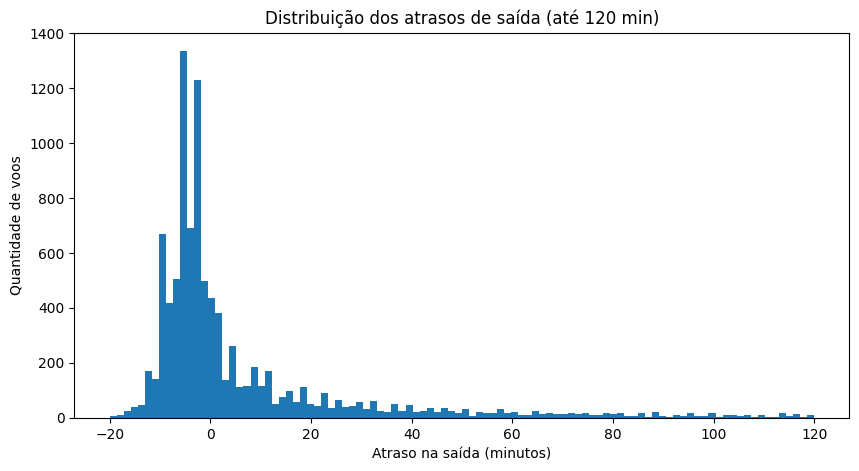

In [74]:
plt.figure(figsize=(10,5))
plt.hist(df['dep_delay'].dropna(), bins=100, range=(-20, 120))
plt.title('Distribuição dos atrasos de saída (até 120 min)')
plt.xlabel('Atraso na saída (minutos)')
plt.ylabel('Quantidade de voos')
plt.show()

## Atraso médio por mês

Nesta etapa, analisei o atraso médio de saída por mês para observar possíveis padrões sazonais.

In [75]:
atraso_mes = df.groupby('month')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

atraso_mes

,count,mean,median
month,,,
1,726,15.01,-2.00
2,711,7.31,-2.00
3,832,13.31,-2.00
4,851,11.60,-2.00
5,824,16.93,-1.00
6,831,17.33,-1.00
7,890,25.73,0.00
8,860,15.27,-2.00
9,831,6.36,-3.00


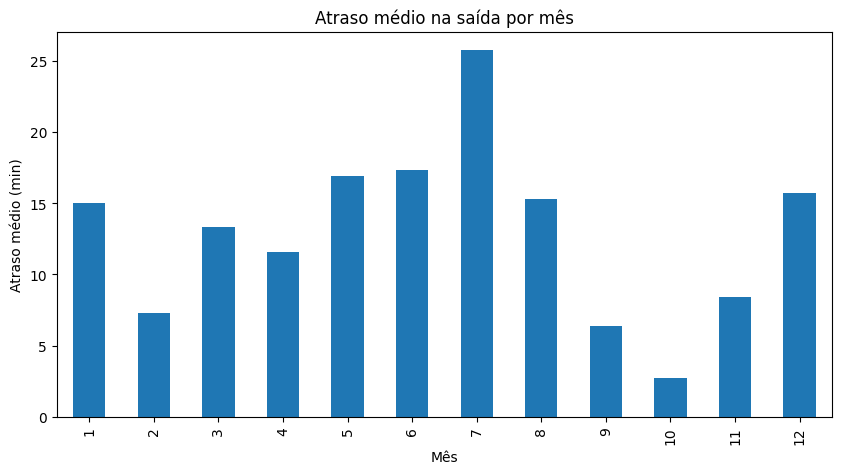

In [76]:
atraso_mes['mean'].plot(kind='bar', figsize=(10,5))
plt.title('Atraso médio na saída por mês')
plt.xlabel('Mês')
plt.ylabel('Atraso médio (min)')
plt.show()

## Atraso médio por hora prevista de saída

Nesta etapa, analisei como o atraso médio varia de acordo com a hora prevista de decolagem.

In [77]:
df['hora_saida_prevista'] = (df['crs_dep_time'] // 100).astype(int)

atraso_hora = df.groupby('hora_saida_prevista')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

atraso_hora

,count,mean,median
hora_saida_prevista,,,
0,13,10.62,12.00
1,7,3.57,-2.00
2,2,0.00,0.00
3,3,-12.67,-18.00
4,1,51.00,51.00
5,279,5.51,-4.00
6,683,8.61,-4.00
7,694,10.01,-3.00
8,671,4.59,-3.00


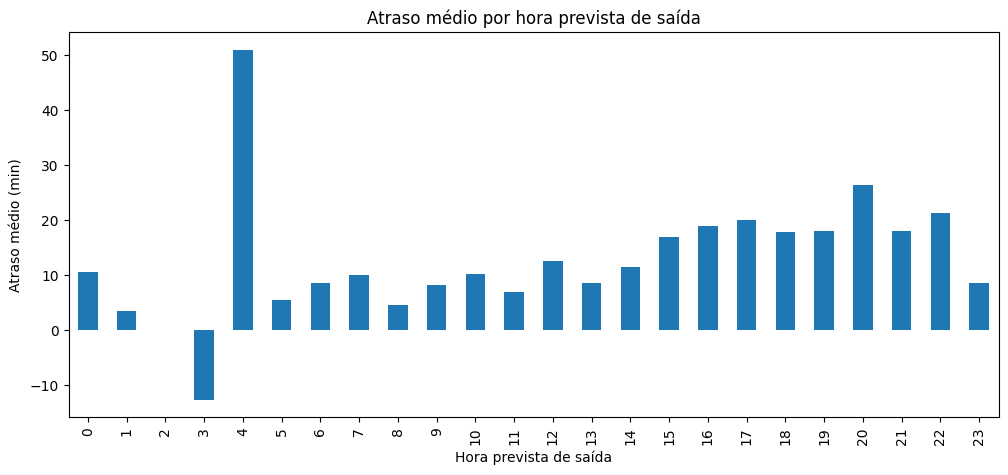

In [78]:
atraso_hora['mean'].plot(kind='bar', figsize=(12,5))
plt.title('Atraso médio por hora prevista de saída')
plt.xlabel('Hora prevista de saída')
plt.ylabel('Atraso médio (min)')
plt.show()

## Criação da variável-alvo

Aqui nessa parte, eu criei a variável `atraso_15min`, que indica se o voo teve atraso superior a 15 minutos na saída.

In [79]:
df_modelo = df.copy()

df_modelo = df_modelo.dropna(subset=['dep_delay'])

df_modelo['atraso_15min'] = (df_modelo['dep_delay'] > 15).astype(int)

df_modelo['atraso_15min'].value_counts(normalize=True) * 100

,proportion
atraso_15min,
0,79.68
1,20.32


## Preparação dos dados para modelagem

Nesta etapa, selecionei as variáveis disponíveis antes da decolagem e transformamos variáveis categóricas em colunas numéricas com one-hot encoding.

In [80]:
colunas_modelo = [
    'month',
    'day_of_month',
    'day_of_week',
    'op_unique_carrier',
    'origin',
    'dest',
    'crs_dep_time',
    'crs_arr_time',
    'distance',
    'atraso_15min'
]

df_modelo = df_modelo[colunas_modelo].copy()

df_modelo.head()

,month,day_of_month,day_of_week,op_unique_carrier,origin,dest,crs_dep_time,crs_arr_time,distance,atraso_15min
0,4,18,4,MQ,DFW,RAP,1018,1149,835.00,0
1,1,1,1,AA,CLT,PHX,1637,1923,1773.00,0
2,12,12,4,9E,CHA,ATL,1000,1059,106.00,0
3,4,8,1,WN,OMA,LAS,1330,1430,1099.00,0
4,2,16,5,WN,BWI,MYR,1340,1510,399.00,0


In [81]:
X = df_modelo.drop('atraso_15min', axis=1)
y = df_modelo['atraso_15min']

X = pd.get_dummies(
    X,
    columns=['op_unique_carrier', 'origin', 'dest'],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X.shape

(9884, 589)

## Regressão Logística

Como a variável alvo está desbalanceada, eu utilizei uma Regressão Logística com balanceamento de classes para avaliar a capacidade do modelo em identificar voos com atraso superior a 15 minutos.

In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.60      0.70      1575
           1       0.27      0.57      0.37       402

    accuracy                           0.60      1977
   macro avg       0.56      0.59      0.54      1977
weighted avg       0.73      0.60      0.64      1977



## Random Forest

Também testei um modelo de Random Forest para comparar o desempenho com a Regressão Logística e avaliar sua capacidade de identificar voos com atraso superior a 15 minutos.

In [83]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1575
           1       0.35      0.03      0.06       402

    accuracy                           0.79      1977
   macro avg       0.58      0.51      0.47      1977
weighted avg       0.71      0.79      0.71      1977



## XGBoost

Por fim, testei o modelo XGBoost, que costuma ter bom desempenho em problemas tabulares e foi utilizado como principal modelo do projeto.

In [84]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977



## Matriz de confusão do XGBoost

Nesta etapa, analisei os acertos e erros do modelo XGBoost para entender melhor sua capacidade de identificar voos com atraso superior a 15 minutos.

In [85]:
confusion_matrix(y_test, y_pred_xgb)

array([[1021,  554],
       [ 152,  250]])

In [86]:
import pandas as pd

matriz_xgb = pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb),
    index=['Real 0 - Sem atraso relevante', 'Real 1 - Atraso > 15 min'],
    columns=['Previsto 0 - Sem atraso relevante', 'Previsto 1 - Atraso > 15 min']
)

matriz_xgb

,Previsto 0 - Sem atraso relevante,Previsto 1 - Atraso > 15 min
Real 0 - Sem atraso relevante,1021,554
Real 1 - Atraso > 15 min,152,250


## Ajuste de limiar de decisão

Nesta etapa, testei diferentes limiares de decisão para o XGBoost, avaliando o equilíbrio entre recall, precision e acurácia na identificação de voos com atraso superior a 15 minutos.

In [87]:
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

limiares = [0.50, 0.40, 0.35]

for limiar in limiares:
    y_pred_limiar = (y_proba_xgb >= limiar).astype(int)

    print(f'\nLimiar: {limiar}')
    print(classification_report(y_test, y_pred_limiar))


Limiar: 0.5
              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977


Limiar: 0.4
              precision    recall  f1-score   support

           0       0.90      0.42      0.58      1575
           1       0.26      0.81      0.40       402

    accuracy                           0.50      1977
   macro avg       0.58      0.62      0.49      1977
weighted avg       0.77      0.50      0.54      1977


Limiar: 0.35
              precision    recall  f1-score   support

           0       0.89      0.29      0.44      1575
           1       0.24      0.87      0.37       402

    accuracy                           0.41      1977
   macro avg       0.57      0.58      0.41      1977
weighted avg       0.76      0.41 

In [88]:
comparacao_limiares = pd.DataFrame({
    'limiar': [0.50, 0.40, 0.35],
    'recall_classe_1': [0.62, 0.81, 0.87],
    'precision_classe_1': [0.31, 0.26, 0.24],
    'acuracia': [0.64, 0.50, 0.41],
    'leitura': [
        'Melhor equilíbrio geral',
        'Mais sensível para detectar atrasos',
        'Recall alto, mas muitos falsos positivos'
    ]
})

comparacao_limiares

,limiar,recall_classe_1,precision_classe_1,acuracia,leitura
0,0.50,0.62,0.31,0.64,Melhor equilíbrio geral
1,0.40,0.81,0.26,0.50,Mais sensível para detectar atrasos
2,0.35,0.87,0.24,0.41,"Recall alto, mas muitos falsos positivos"


## Curva ROC e AUC

Nesta etapa, avaliei a capacidade do XGBoost de separar voos com e sem atraso relevante, utilizando a curva ROC e a métrica AUC.

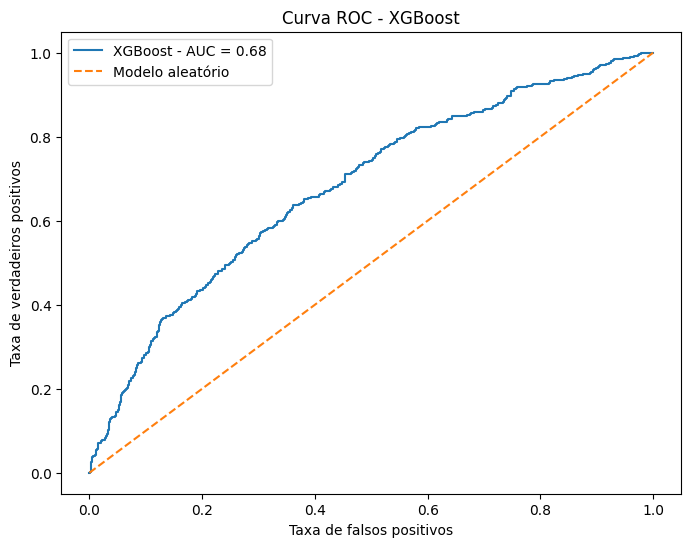

AUC: 0.6804722419647793


In [89]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost - AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatório')
plt.title('Curva ROC - XGBoost')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()
plt.show()

print("AUC:", auc)

## Conclusão

Durante a análise exploratória, identifiquei que a média de atraso pode ser influenciada por atrasos extremos, por isso a mediana também foi importante para interpretar melhor os dados.

Entre os modelos testados, o XGBoost apresentou o melhor desempenho para identificar voos com atraso relevante, alcançando recall de 62% na classe 1 e AUC aproximada de 0,68.

Apesar do modelo ainda apresentar falsos positivos, ele funcionou como uma boa prova de conceito para análise preditiva aplicada ao contexto de aviação.